<a href="https://colab.research.google.com/github/Alex-Devoid/st554-HW5/blob/main/st554_HW5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW5 — Bias in data and models; SQL Practice.

Name: Alex Devoid  
Course: ST 554 (Spring 2026)

## Part I — Five V’s of Big Data


### 1.
Parcel-level tax / assessor data

We can think about this data using the “Five V’s” framing:
- **Volume**: number of parcels can be huge, especially if we were to aggregate them across the nation.
- **Velocity**: updates arrive on different cadences, like annual reassessment, general sales activity and re-zoning.
- **Variety**: Fields include tax roll info, spatial geometry, sales records, zoning codes, address strings
- **Veracity**: missing/outdated owner names, inconsistent addresses, partial sales data and miscoded land use.
- **Value**: once cleaned we can measure property tax contributions, model change over time, identify inequities, and support community planning.

### 2.

### CRUD - Create, Read, Update, Delete

### **Create**: add new records
```sql
INSERT INTO People(playerID, nameFirst, nameLast)
VALUES ('adevoid01', 'Alex', 'Devoid');
```

### **Read**: query existing records
```sql
SELECT playerID, nameFirst, nameLast
FROM People
WHERE nameLast = 'Devoid';
```

### **Update**: edit records
```sql
UPDATE People
SET nameFirst = 'Al'
WHERE playerID = 'alDevoid01';
```

### **Delete** removes records
```sql
DELETE FROM People
WHERE playerID = 'alDevoid01';
```

### 3.
The `HAVING` clause is used to filter results after an aggregation step like `GROUP BY`.


# Part II — Simulation of a Sampling Distribution



In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [130]:
# Simulation settings
# using Seeded random number generator
rng = np.random.default_rng(554)



# number of simulations
B = 5000
# the “true” intercept used to generate y
beta0_true = 7.0
# the “true” slope used to generate y, how much y changes when x increases by 1.
beta1_true = 1.5
#  get three 'values' of x at each integer from 0 to 10
x = np.array(list(np.linspace(start=0, stop=10, num=11)) * 3)
# sample size
n = len(x)
# larger sigma would mean more scattering around the true line
sigma = 1.0

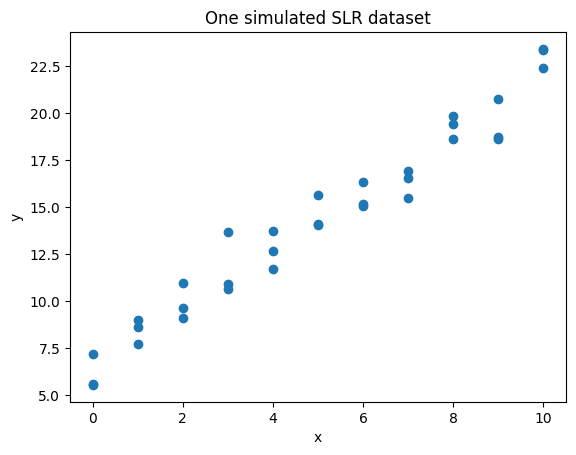

In [131]:
# single draw from the SLR model
eps_demo = rng.standard_normal(n)
y_demo = beta0_true + beta1_true * x + sigma * eps_demo

plt.scatter(x=x, y=y_demo)
plt.title("One simulated SLR dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [132]:
from sklearn.linear_model import LinearRegression

# store slope estimates from each simulated dataset
slopes = np.zeros(B)

for b in range(B):

    # generate error terms using standard normal distribution
    eps = rng.standard_normal(n)

    # generate response values using the SLR model
    # Yi = beta0 + beta1 * xi + Ei
    y = beta0_true + beta1_true * x + sigma * eps

    # fit SLR using sklearn
    # and find the least squares estimate of the slope
    model = LinearRegression().fit(x.reshape(-1, 1), y)

    # save estimated slope
    slopes[b] = model.coef_[0]

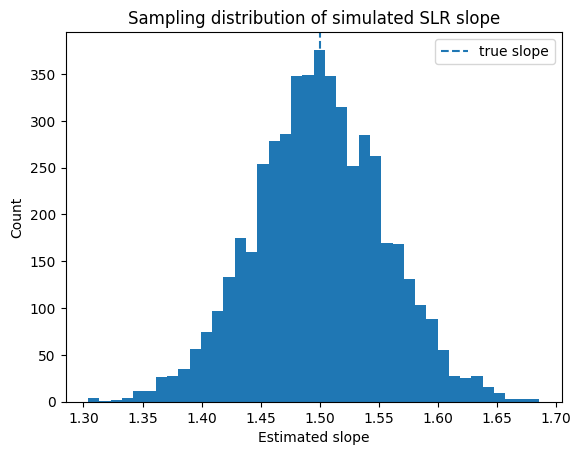

In [133]:
# taking a look at the sampling distribution
plt.figure()
plt.hist(slopes, bins=40)
plt.axvline(beta1_true, linestyle="--", label="true slope")
plt.title("Sampling distribution of simulated SLR slope")
plt.xlabel("Estimated slope")
plt.ylabel("Count")
plt.legend()
plt.show()

In [134]:
# Approximate P(sample slope > 1.65)
prob_gt_165 = float(np.mean(slopes > 1.65))
print("Approx P(slope_hat > 1.65):", prob_gt_165)

Approx P(slope_hat > 1.65): 0.0036


### Interpretation of Approx P(slope_hat > 1.65)

In this simulation, the estimated probability of getting a sample slope larger than 1.65 was 0.0036.  
That means about 0.36% of the 5000 simulated datasets produced a fitted slope above 1.65. Slopes above 1.65 are extremely rare in the simulation. In a one-sided hypothesis test, that would be considered strong evidence against the “null” model that generated the simulation.


## Part III — Big Data Examples & Rare Events

### 5.
### Biases in ML models (ICRC article)
**Example bias issue from the article:**  
When the training data reflects unequal coverage or unequal reporting, the model learns patterns that are “true in the dataset” but not fair or valid in the real world.

For example if something like violent crimes are more frequently documented in some areas or groups than others, an Statistical Learning system trained on those records will over-represent those area or groups regions in predictions.

**How to augment / account for bias:**  
- We can augment with additional data sources. For example, we could cover under-reported areas or groups with data from data collected by a third party like an NGO. We could also search for other channels in which a violent crime could have been reported and documented outside triage that built our initial data.
- We can model uncertainty or missingness explicitly by treating observations as “observed events” not “all events,” and be cautious about interpreting absence as zero.
- We can conduct a stratified evaluation by checking model error rates separately by area or group to see if performance is uneven.
- Use a model's prediction as supporting evidence but not proof.

Generally speaking, if the collection process is biased, you can’t fix it just by “better modeling.” We can either either improve the data, or you design the analysis to reflect data limitations.


### Big data in Earth sciences
### 6.

Atmospheric science  

How big data is used:  
- Atmospheric science pulls together huge spatiotemporal datasets like satellite data, radar data, data from weather stations and reanalysis grids. Then the data is used to model patterns over space and time.
- A lot of the big data work is building pipelines that turn raw measurements into usable information and then using that information to improve forecasts and understanding.  
- The paper frames this as part of a bigger push toward more integrated, high-resolution modeling and “digital twin” thinking that uses large data and models together.  

Biases / missing data that could affect results (best-effort, non–Earth-scientist view):
- Uneven observation coverage: some regions and time periods are measured more densely than others due to fewer sensors, missing satellite passes or outages, which can make “global” conclusions lean toward what’s easiest to measure.
- Detectability bias: some events or conditions are easier to detect than others, so the dataset can overrepresent what’s detectable and underrepresent what’s not.



### Rare Events
### 7.

In a parcel-level property tax dataset, lets say in Buncombe County for example, a hurricane like Helene is a rare “tail” event that can wipe out an entire business district in the parcel dataset in one shock. And the Superbolts point is that if you model those tails with the wrong distribution, too light for example, you’ll seriously underestimate how often these high-impact events happen and misjudge risk and planning decisions.

## Part IV

## Querying a database



In [135]:
# Connect to Lahman SQLite database

conn = sqlite3.connect("/content/lahman_1871-2022.sqlite")

In [136]:
# 8 Look at all tables in the database
# querying SQLite’s catalog table, sqlite_master, to discover the database schema, then returning all tables
tables_df = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
tables_df

,name
0,AllstarFull
1,Appearances
2,AwardsManagers
3,AwardsPlayers
4,AwardsShareManagers
5,AwardsSharePlayers
6,Batting
7,BattingPost
8,CollegePlaying
9,Fielding


In [137]:
# 9 All teams that played in 2015 with all columns
# SELECT * returns every column, and WHERE filters rows to just the 2015 season.
teams_2015 = pd.read_sql("SELECT * FROM Teams WHERE yearID = 2015;", conn)
teams_2015.head()

,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,...,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,2015,AL,BAL,BAL,E,3,162,78,81,81,...,134,0.987,Baltimore Orioles,Oriole Park at Camden Yards,2281202,103,104,BAL,BAL,BAL
1,2015,AL,BOS,BOS,E,5,162,81,78,84,...,148,0.984,Boston Red Sox,Fenway Park II,2880694,104,107,BOS,BOS,BOS
2,2015,AL,CHA,CHW,C,4,162,81,76,86,...,159,0.983,Chicago White Sox,U.S. Cellular Field,1755810,92,93,CHW,CHA,CHA
3,2015,AL,CLE,CLE,C,3,161,80,81,80,...,136,0.987,Cleveland Indians,Progressive Field,1388905,106,106,CLE,CLE,CLE
4,2015,AL,DET,DET,C,5,161,81,74,87,...,165,0.986,Detroit Tigers,Comerica Park,2726048,97,98,DET,DET,DET


In [138]:
## 10 All inducted Hall of Fame entries: playerID, yearID, category
# the WHERE clause filters to only rows where the person was actually inducted ('Y')
hof = pd.read_sql("""
SELECT playerID, yearID, category
FROM HallOfFame
WHERE inducted = 'Y';
""", conn)

hof.head(), hof.shape

(    playerID  yearid category
 0  aaronha01    1982   Player
 1  alexape01    1938   Player
 2  alomaro01    2011   Player
 3  alstowa01    1983  Manager
 4  andersp01    2000  Manager,
 (340, 3))

In [139]:
# 11 Unique managers of the Pittsburgh Pirates (teamID = 'PIT')
# DISTINCT removes duplicate manager IDs across many seasons in the Managers table.
pit_mgrs = pd.read_sql("""
SELECT DISTINCT playerID
FROM Managers
WHERE teamID = 'PIT';
""", conn)

pit_mgrs.head(), pit_mgrs.shape

(    playerID
 0  bezdehu99
 1  bragabo01
 2  buckeal99
 3  burnsto01
 4  burwebi01,
 (41, 1))

In [140]:
# 12 PlayerIDs who managed and were inducted into the Hall of Fame
# The INNER JOIN keeps only overlaping IDs that appear in both tables
hof_mgr_ids = pd.read_sql("""
SELECT DISTINCT m.playerID
FROM Managers AS m
INNER JOIN HallOfFame AS h
    ON m.playerID = h.playerID
WHERE h.inducted = 'Y';
""", conn)

hof_mgr_ids.head(), hof_mgr_ids.shape

(    playerID
 0  alstowa01
 1  andersp01
 2  ansonca01
 3  applilu01
 4  baineha01,
 (97, 1))

In [141]:
# Programmatically report the number these players by printing the unique occurances of player IDs
num_hof_mgrs = hof_mgr_ids["playerID"].nunique()
num_hof_mgrs

97

In [142]:
# 13 Every season managed by each Hall of Fame manager (return playerID, G, W, L)
# join Managers to a DISTINCT list of inducted playerIDs to avoid duplicating seasons.
hof_manager_seasons = pd.read_sql(
    """
    SELECT m.playerID, m.G, m.W, m.L
    FROM Managers AS m
    INNER JOIN (
        SELECT DISTINCT playerID
        FROM HallOfFame
        WHERE inducted = 'Y'
    ) AS h
        ON m.playerID = h.playerID;
    """,
    conn
)

hof_manager_seasons.head()

,playerID,G,W,L
0,alstowa01,154,92,62
1,alstowa01,154,98,55
2,alstowa01,154,93,61
3,alstowa01,154,84,70
4,alstowa01,154,71,83


In [143]:
# Overall win/loss totals + win% for each Hall of Fame manager, sorted by win%
# this is the same idea as SQL GROUP BY + aggregation, but done in pandas after the SQL join.
mgr_summary = (
    hof_manager_seasons
    .groupby("playerID", as_index=False)[["W", "L"]]
    .sum()
)

mgr_summary["win_pct"] = mgr_summary["W"] / (mgr_summary["W"] + mgr_summary["L"])
mgr_summary = mgr_summary.sort_values("win_pct", ascending=False)

mgr_summary.head(10)

,playerID,W,L,win_pct
75,simmote01,1,0,1.000000
94,wrighge01,59,25,0.702381
78,spaldal01,78,47,0.624000
57,mccarjo99,2125,1333,0.614517
19,comisch01,840,541,0.608255
74,seleefr99,1284,862,0.598322
77,southbi01,1044,704,0.597254
13,chancfr01,946,648,0.593476
59,mcgrajo01,2763,1948,0.586500
51,lopezal01,1410,1004,0.584093


In [144]:
conn.close()